In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to the root of the project
%cd /content/drive/MyDrive/ml-ds-projects/telecom-churn-predictor/

# Run your production script!
!python src/data_cleaning.py

Mounted at /content/drive
/content/drive/MyDrive/ml-ds-projects/telecom-churn-predictor
Loading raw data from: data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dropped 'customerID' column.
Forced TotalCharges to numeric. Dropped 11 rows with missing values.

✅ Clean data saved successfully to: data/processed/cleaned_churn_data.csv
Final Dataset Shape: (7032, 20)


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the perfectly clean data
df = pd.read_csv('data/processed/cleaned_churn_data.csv')

# 2. Separate features (X) and target (y)
X = df.drop('Churn', axis=1)

# 3. Convert target to a binary integer (Yes = 1, No = 0)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Stratified Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (5625, 19)
Testing set: (1407, 19)


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define which columns need which transformations
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Exclude numeric features and the target from the categorical list
categorical_features = [col for col in X.columns if col not in numeric_features]

# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # drop='first' prevents multi-collinearity (the dummy variable trap)
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

print("Preprocessor engine successfully built!")

Preprocessor engine successfully built!


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Create a master pipeline with a placeholder classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression()) # This will be swapped out dynamically
])

# 2. Define the parameter grid testing all three models
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7, 9, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 5, 10]
    }
]

# 3. Initialize GridSearchCV optimizing explicitly for Recall
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

print("Training models and tuning hyperparameters...")
grid_search.fit(X_train, y_train)

print(f"\n✅ Optimization Complete!")
print(f"Best Model Found: {grid_search.best_params_['classifier']}")
print(f"Best Cross-Validation Recall Score: {grid_search.best_score_:.4f}")

Training models and tuning hyperparameters...
Fitting 5 folds for each of 26 candidates, totalling 130 fits

✅ Optimization Complete!
Best Model Found: KNeighborsClassifier()
Best Cross-Validation Recall Score: 0.5619


In [6]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Extract the absolute best-performing pipeline from the grid search
best_pipeline = grid_search.best_estimator_

# 2. Predict hard classes (0 or 1) and raw probabilities for the test set
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# 3. Print out the comprehensive evaluation metrics
print("================ CLASSICAL METRICS REPORT ================")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# 4. Calculate the Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

================ CLASSICAL METRICS REPORT ================
              precision    recall  f1-score   support

    Retained       0.84      0.86      0.85      1033
     Churned       0.58      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC Score: 0.8094


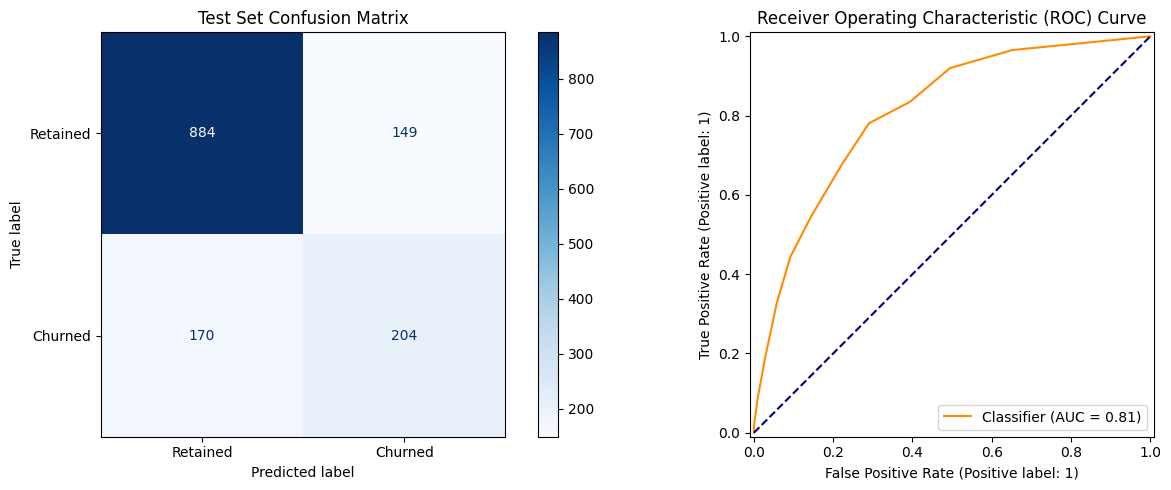

In [7]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set up a 1x2 grid for subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Visual Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Retained', 'Churned'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Test Set Confusion Matrix')
axes[0].grid(False) # Turn off grid lines for clean layout

# Plot 2: ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    ax=axes[1],
    color='darkorange'
)
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--') # Baseline random guess line
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')

plt.tight_layout()
plt.show()